# VerifiedJS: Multi-Agent Proof Evolution Analysis

Analyzing 3000+ commits from 4 autonomous AI agents building a formally verified JS-to-Wasm compiler.

In [98]:
import git
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from IPython.display import HTML, display
import re
from datetime import datetime, timezone
from collections import defaultdict, Counter
import numpy as np

# ── Basis.ai theme ──────────────────────────────────────────────
BASIS = {
    'text': '#311317', 'accent': '#ff4500', 'warm': '#e0d4c1',
    'bg': '#ffffff', 'muted': '#8a7e72', 'light': '#f5f0eb',
    'green': '#2d6a4f', 'blue': '#1d3557', 'orange': '#e76f51', 'purple': '#6d4c7d',
}
PALETTE = ['#ff4500', '#311317', '#2d6a4f', '#1d3557', '#e76f51', '#6d4c7d', '#8a7e72']

plt.rcParams.update({
    'figure.figsize': (12, 4.5), 'figure.facecolor': '#fff', 'figure.dpi': 150,
    'axes.facecolor': '#fff', 'axes.edgecolor': '#e0d4c1', 'axes.labelcolor': '#311317',
    'axes.titlesize': 14, 'axes.titleweight': 'normal', 'axes.grid': True,
    'grid.color': '#f0ebe4', 'grid.linewidth': 0.5,
    'text.color': '#311317', 'xtick.color': '#8a7e72', 'ytick.color': '#8a7e72',
    'font.family': 'serif',
    'font.serif': ['Plantin', 'Georgia', 'Times New Roman', 'serif'],
    'font.sans-serif': ['Basier', 'Helvetica Neue', 'Arial'],
    'legend.framealpha': 0.9, 'legend.edgecolor': '#e0d4c1',
})

basis_tpl = go.layout.Template(layout=go.Layout(
    font=dict(family='Basier, Helvetica Neue, sans-serif', color='#311317', size=12),
    paper_bgcolor='#fff', plot_bgcolor='#faf7f4', colorway=PALETTE,
    title=dict(font=dict(family='Plantin, Georgia, serif', size=18, color='#311317')),
    xaxis=dict(gridcolor='#ede8e2', linecolor='#e0d4c1', tickfont=dict(size=10)),
    yaxis=dict(gridcolor='#ede8e2', linecolor='#e0d4c1', tickfont=dict(size=10)),
    legend=dict(bgcolor='rgba(255,255,255,0.9)', bordercolor='#e0d4c1', borderwidth=1, font=dict(size=11)),
))
pio.templates['basis'] = basis_tpl
pio.templates.default = 'none+basis'  # 'none' clears plotly_dark etc, then apply basis

# ── Lean syntax highlighting (HTML) ────────────────────────────
_LEAN_KW = set('theorem lemma def inductive structure instance class where by sorry '
    'import open namespace end section private protected noncomputable partial mutual '
    'match with if then else do let have show exact simp omega aesop grind decide '
    'cases intro apply constructor rfl fun forall exists Prop Type Bool Nat true false return'.split())

def lean_html(code, title=None):
    """Render Lean code as syntax-highlighted HTML in the notebook."""
    import html as _html
    lines = code.split('\n')
    out_lines = []
    for line in lines:
        # Handle comments first (preserve rest of line)
        comment = ''
        if '--' in line:
            idx = line.index('--')
            comment = _html.escape(line[idx:])
            comment = f'<span style="color:#8a7e72;font-style:italic">{comment}</span>'
            line = line[:idx]

        # Tokenize and highlight
        tokens = re.split(r'(\b\w+\b|[^\w\s]|\s+)', line)
        out = []
        for tok in tokens:
            if tok in _LEAN_KW:
                if tok == 'sorry':
                    out.append(f'<span style="background:#fff0e0;color:#ff4500;font-weight:700;padding:1px 3px;border-radius:2px">{tok}</span>')
                else:
                    out.append(f'<span style="color:#6d4c7d;font-weight:600">{tok}</span>')
            elif tok and tok[0].isupper() and re.match(r'^[A-Z][A-Za-z0-9_.]+$', tok):
                out.append(f'<span style="color:#1d3557">{_html.escape(tok)}</span>')
            elif tok.startswith('"') or tok.startswith("'"):
                out.append(f'<span style="color:#2d6a4f">{_html.escape(tok)}</span>')
            else:
                out.append(_html.escape(tok))
        out_lines.append(''.join(out) + comment)

    body = '\n'.join(out_lines)
    title_html = f'<div style="font-family:Basier,Helvetica Neue,sans-serif;font-size:11px;color:#8a7e72;margin-bottom:6px;font-weight:600">{_html.escape(title)}</div>' if title else ''
    return HTML(
        f'<div style="background:#faf7f4;border:1px solid #e0d4c1;border-radius:6px;'
        f'padding:14px 18px;margin:8px 0;font-family:Basier Mono,SF Mono,Fira Code,monospace;'
        f'font-size:12.5px;line-height:1.7;overflow-x:auto">'
        f'{title_html}<pre style="margin:0;white-space:pre-wrap">{body}</pre></div>'
    )

def show_lean(code, title=None):
    display(lean_html(code, title))

# ── LeanSplitter binary wrapper (replaces lean_parser.py regex-based parsing) ──
import subprocess, tempfile, hashlib, json, os, pickle

_LEANSPLITTER_BIN = '.lake/build/bin/leansplitter'
_LEANSPLITTER_CACHE_DIR = '.leansplitter_cache'
os.makedirs(_LEANSPLITTER_CACHE_DIR, exist_ok=True)

def _cache_path(content_hash):
    return os.path.join(_LEANSPLITTER_CACHE_DIR, f'{content_hash}.json')

def _extract_cases_from_text(lines):
    """Extract match cases from declaration text lines.
    Looks for `| .name` or `| «name»` patterns."""
    cases = {}
    current_label = None
    current_lines = []
    for line in lines:
        stripped = line.lstrip()
        if stripped.startswith('| .') or stripped.startswith('| \u00ab'):
            if current_label is not None and current_lines:
                cases[current_label] = '\n'.join(current_lines)
            after_pipe = stripped[2:].lstrip()
            if after_pipe.startswith('.'):
                rest = after_pipe[1:]
                name_chars = []
                for ch in rest:
                    if ch in ' (\n,|':
                        break
                    name_chars.append(ch)
                current_label = ''.join(name_chars)
            elif after_pipe.startswith('\u00ab'):
                current_label = after_pipe[1:].split('\u00bb')[0]
            else:
                current_label = after_pipe.split()[0] if after_pipe.split() else '?'
            current_lines = [line]
        elif current_label is not None:
            current_lines.append(line)
    if current_label is not None and current_lines:
        cases[current_label] = '\n'.join(current_lines)
    return cases

def parse_lean_file(content):
    """Parse a Lean file using the compiled leansplitter binary.
    Returns: {'declarations': [{'kind', 'name', 'line', 'end_line', 'body', 'sorry', 'cases', ...}]}
    Falls back to lean_parser.py if binary fails."""
    h = hashlib.sha256(content.encode()).hexdigest()[:16]
    cp = _cache_path(h)
    if os.path.exists(cp):
        with open(cp) as f:
            return json.load(f)

    # Write content to temp file, run binary
    with tempfile.NamedTemporaryFile(suffix='.lean', mode='w', delete=False) as tf:
        tf.write(content)
        tf.flush()
        try:
            result = subprocess.run(
                ['lake', 'env', _LEANSPLITTER_BIN, tf.name],
                capture_output=True, text=True, timeout=120, cwd=os.getcwd()
            )
            if result.returncode == 0 and result.stdout.strip():
                decls_raw = json.loads(result.stdout)
                decls = []
                for d in decls_raw:
                    body = d.get('text', '')
                    # Extract match cases from text (syntax tree cases may be empty)
                    cases_from_stx = {c['name']: c.get('text', '') for c in d.get('cases', [])}
                    cases = cases_from_stx if cases_from_stx else _extract_cases_from_text(body.splitlines())
                    decls.append({
                        'kind': d.get('kind', '?'),
                        'name': d.get('name', '?'),
                        'line': d.get('start_line', 0),
                        'end_line': d.get('end_line', 0),
                        'body': body,
                        'sorry': d.get('has_sorry', False),
                        'cases': cases,
                        'num_lines': d.get('end_line', 0) - d.get('start_line', 0),
                        'is_private': d.get('is_private', False),
                        'num_cases': d.get('num_cases', len(cases)),
                    })
                out = {'declarations': decls}
                with open(cp, 'w') as f:
                    json.dump(out, f)
                return out
        except (subprocess.TimeoutExpired, json.JSONDecodeError, FileNotFoundError):
            pass
        finally:
            os.unlink(tf.name)

    # Fallback: Python parser
    from lean_parser import parse_lean_file as _py_parse
    return _py_parse(content)


def parse_step_function(content, func_name='step?'):
    """Extract cases from a specific step function."""
    result = parse_lean_file(content)
    for decl in result['declarations']:
        if decl['name'] == func_name:
            return decl['cases'], decl['body']
    return {}, ''


def diff_cases(old, new):
    """Diff two case dicts. Returns (added, removed, changed)."""
    added = {k: v for k, v in new.items() if k not in old}
    removed = {k: v for k, v in old.items() if k not in new}
    changed = {k: (old[k], new[k]) for k in old if k in new and old[k] != new[k]}
    return added, removed, changed

repo = git.Repo('.')
print(f'Repo: {repo.working_dir}')
print(f'Commits: {sum(1 for _ in repo.iter_commits())}')
print(f'HEAD: {repo.head.commit.hexsha[:8]} {repo.head.commit.summary}')

Repo: /Users/kirancodes/Documents/code/VerifiedJS
Commits: 3028
HEAD: ffd4cc62 added agent logs


python3(82283) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82284) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82286) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


## 1. Parse All Commits

In [82]:
# Parse commit messages for stats (auto-snapshot commits have structured messages)
commits = []
for c in repo.iter_commits('main'):
    msg = c.summary
    m = re.match(r'auto: (\d+) sorries, (\d+) lean files, (\d+) LOC \[(.*)\]', msg)
    agents = []
    sorries = loc = lean_files = None
    if m:
        sorries = int(m.group(1))
        lean_files = int(m.group(2))
        loc = int(m.group(3))
        agents = [a.strip() for a in m.group(4).split() if a.strip() and a.strip() != 'none']
    
    commits.append({
        'hash': c.hexsha[:8],
        'ts': datetime.fromtimestamp(c.authored_date),
        'author': c.author.name,
        'msg': msg,
        'sorries': sorries,
        'loc': loc,
        'lean_files': lean_files,
        'agents': agents,
        'files_changed': len(c.stats.files),
        'insertions': c.stats.total.get('insertions', 0),
        'deletions': c.stats.total.get('deletions', 0),
    })

df = pd.DataFrame(commits)
df = df.sort_values('ts').reset_index(drop=True)
df_auto = df[df['sorries'].notna()].copy()
print(f'Total commits: {len(df)}')
print(f'Auto-snapshot commits (with stats): {len(df_auto)}')
print(f'Date range: {df.ts.min()} → {df.ts.max()}')
df_auto.tail()

python3(20491) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(20492) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(20493) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(20494) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(20495) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(20536) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(20578) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(20633) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(20634) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(20635) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(20

Total commits: 3025
Auto-snapshot commits (with stats): 2859
Date range: 2026-03-07 17:22:19 → 2026-04-01 09:34:16


,hash,ts,author,msg,sorries,loc,lean_files,agents,files_changed,insertions,deletions
3018,8f855aeb,2026-04-01 09:00:01,VerifiedJS Agents,"auto: 41 sorries, 47 lean files, 101740 LOC [s...",41.0,101740.0,47.0,[supervisor],4,9,4
3019,cd78fea5,2026-04-01 09:05:01,VerifiedJS Agents,"auto: 41 sorries, 47 lean files, 101740 LOC [s...",41.0,101740.0,47.0,[supervisor],7,24,8
3020,426b7329,2026-04-01 09:10:01,VerifiedJS Agents,"auto: 41 sorries, 47 lean files, 101740 LOC [s...",41.0,101740.0,47.0,[supervisor],2,7,5
3021,6f91299e,2026-04-01 09:15:01,VerifiedJS Agents,"auto: 41 sorries, 47 lean files, 101740 LOC [n...",41.0,101740.0,47.0,[],1,4,4
3022,56093ae3,2026-04-01 09:20:01,VerifiedJS Agents,"auto: 41 sorries, 47 lean files, 101740 LOC [s...",41.0,101740.0,47.0,[supervisor],6,15,8


## 2. Sorry Count & LOC Over Time

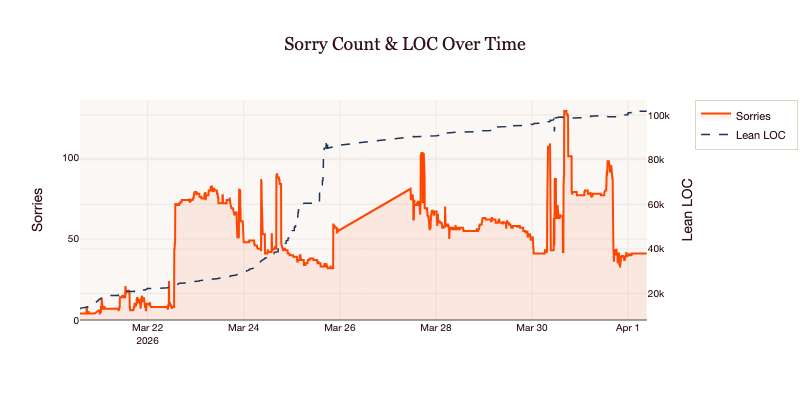

In [100]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(
    x=df_auto['ts'], y=df_auto['sorries'],
    name='Sorries', line=dict(color='#ff4500', width=2),
    fill='tozeroy', fillcolor='rgba(255,69,0,0.08)'
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=df_auto['ts'], y=df_auto['loc'],
    name='Lean LOC', line=dict(color='#1d3557', width=1.5, dash='dash'),
), secondary_y=True)

fig.update_layout(
    title='Sorry Count & LOC Over Time',
    height=400,
)
fig.update_yaxes(title_text='Sorries', secondary_y=False)
fig.update_yaxes(title_text='Lean LOC', secondary_y=True)
fig.show()

## 3. Agent Activity Heatmap

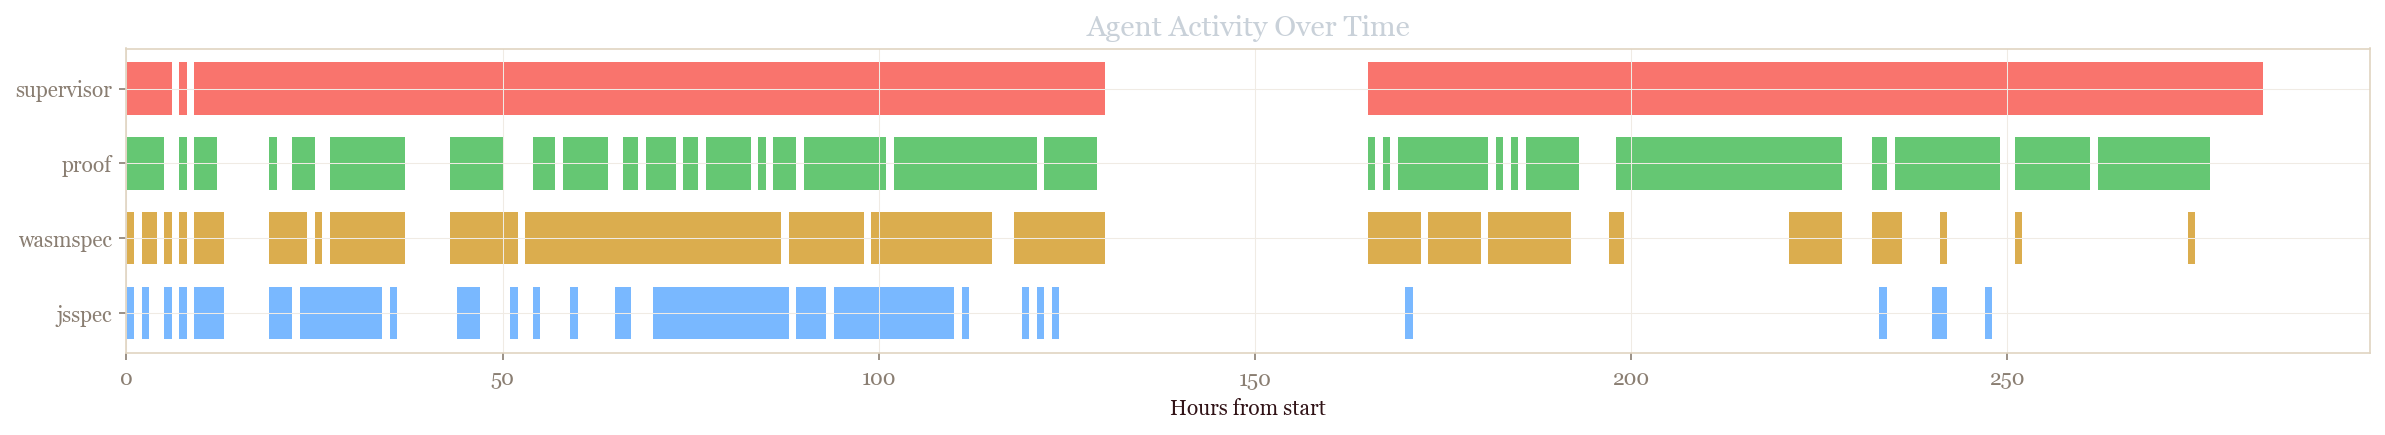

In [101]:
# Which agents were active in each commit?
agent_names = ['jsspec', 'wasmspec', 'proof', 'supervisor']
for a in agent_names:
    df_auto[a] = df_auto['agents'].apply(lambda x: 1 if a in x else 0)

# Resample to hourly
df_hourly = df_auto.set_index('ts')[agent_names].resample('1h').max().fillna(0)

fig, ax = plt.subplots(figsize=(16, 3))
colors = {'jsspec': '#58a6ff', 'wasmspec': '#d29922', 'proof': '#3fb950', 'supervisor': '#f85149'}
for i, a in enumerate(agent_names):
    active = df_hourly[a].values
    for j, v in enumerate(active):
        if v > 0:
            ax.barh(i, 1, left=j, color=colors[a], alpha=0.8, height=0.7)
ax.set_yticks(range(4))
ax.set_yticklabels(agent_names)
ax.set_xlabel('Hours from start')
ax.set_title('Agent Activity Over Time', color='#c9d1d9')
plt.tight_layout()
plt.show()

## 4. Lightweight Lean Parser — Track Definitions Over Commits

In [102]:
def parse_lean_declarations(content):
    """Extract declarations using leansplitter binary."""
    result = parse_lean_file(content)
    return [{
        'kind': d['kind'],
        'name': d['name'],
        'private': d.get('is_private', d['body'][:50].startswith('private') if d.get('body') else False),
        'line': d['line'],
        'sorry': d['sorry'],
        'signature': d.get('body', ''),
        'cases': d.get('cases', {}),
        'num_lines': d.get('num_lines', 0),
    } for d in result['declarations']]

# Test on current file
with open('VerifiedJS/Proofs/LowerCorrect.lean') as f:
    decls = parse_lean_declarations(f.read())
for d in decls:
    status = '❌ sorry' if d['sorry'] else '✅'
    print(f"  {d['kind']} {d['name']} {status}")

python3(82484) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  theorem runtimeIdx_getGlobal_fresh_from_arith ✅
  theorem runtimeIdx_getGlobal_after_numeric_helpers ✅
  theorem lower_correct ✅
  theorem lower_exports_correct ✅
  theorem lower_memory_correct ✅
  theorem lower_behavioral_correct ✅


## 5. Track a File's Evolution Across Commits

In [103]:
def track_file_evolution(filepath, sample_every=10):
    """Track declarations in a file across commits."""
    history = []
    commits_touching = list(repo.iter_commits('main', paths=filepath))
    commits_touching.reverse()  # oldest first
    
    for i, c in enumerate(commits_touching):
        if i % sample_every != 0 and i != len(commits_touching) - 1:
            continue
        try:
            blob = c.tree / filepath
            content = blob.data_stream.read().decode('utf-8', errors='replace')
            decls = parse_lean_declarations(content)
            sorry_count = sum(1 for d in decls if d['sorry'])
            thm_count = sum(1 for d in decls if d['kind'] in ('theorem', 'lemma'))
            def_count = sum(1 for d in decls if d['kind'] == 'def')
            ind_count = sum(1 for d in decls if d['kind'] == 'inductive')
            struct_count = sum(1 for d in decls if d['kind'] == 'structure')
            lines = len(content.splitlines())
            
            history.append({
                'ts': datetime.fromtimestamp(c.authored_date),
                'hash': c.hexsha[:8],
                'lines': lines,
                'theorems': thm_count,
                'defs': def_count,
                'inductives': ind_count,
                'structures': struct_count,
                'sorries': sorry_count,
                'decl_names': [d['name'] for d in decls if d['kind'] in ('theorem', 'lemma')],
            })
        except (KeyError, TypeError):
            pass
    
    return pd.DataFrame(history)

# Track ClosureConvertCorrect evolution
cc_hist = track_file_evolution('VerifiedJS/Proofs/ClosureConvertCorrect.lean', sample_every=5)
print(f'{len(cc_hist)} snapshots')
cc_hist.tail()

python3(82641) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82643) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82689) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82735) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82756) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82803) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82849) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82878) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82927) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82973) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(82

111 snapshots


,ts,hash,lines,theorems,defs,inductives,structures,sorries,decl_names
106,2026-03-31 23:25:01,1fc2719d,7250,218,14,0,0,2,"[firstNonValueExpr_not_lit, firstNonValueProp_..."
107,2026-04-01 00:20:02,00845152,7257,218,14,0,0,2,"[firstNonValueExpr_not_lit, firstNonValueProp_..."
108,2026-04-01 01:10:01,7710654e,7275,218,14,0,0,2,"[firstNonValueExpr_not_lit, firstNonValueProp_..."
109,2026-04-01 02:00:01,4eac9708,7394,218,14,0,0,2,"[firstNonValueExpr_not_lit, firstNonValueProp_..."
110,2026-04-01 02:25:01,a891ae80,7302,218,14,0,0,2,"[firstNonValueExpr_not_lit, firstNonValueProp_..."


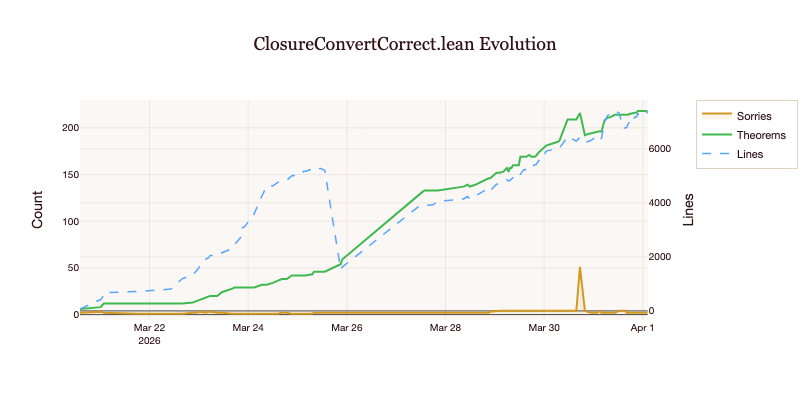

In [104]:
# Plot CC evolution
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=cc_hist['ts'], y=cc_hist['sorries'], name='Sorries',
    line=dict(color='#d29922', width=2), fill='tozeroy', fillcolor='rgba(210,153,34,0.1)'), secondary_y=False)
fig.add_trace(go.Scatter(x=cc_hist['ts'], y=cc_hist['theorems'], name='Theorems',
    line=dict(color='#3fb950', width=2)), secondary_y=False)
fig.add_trace(go.Scatter(x=cc_hist['ts'], y=cc_hist['lines'], name='Lines',
    line=dict(color='#58a6ff', width=1.5, dash='dash')), secondary_y=True)
fig.update_layout(title='ClosureConvertCorrect.lean Evolution', height=400)
fig.update_yaxes(title_text='Count', secondary_y=False)
fig.update_yaxes(title_text='Lines', secondary_y=True)
fig.show()

## 6. Theorem Statement Evolution

In [105]:
def track_theorem_signatures(filepath, theorem_name, sample_every=5):
    """Track how a specific theorem's signature changes across commits."""
    history = []
    commits_touching = list(repo.iter_commits('main', paths=filepath))
    commits_touching.reverse()
    
    prev_sig = None
    for i, c in enumerate(commits_touching):
        if i % sample_every != 0 and i != len(commits_touching) - 1:
            continue
        try:
            blob = c.tree / filepath
            content = blob.data_stream.read().decode('utf-8', errors='replace')
            decls = parse_lean_declarations(content)
            match = [d for d in decls if d['name'] == theorem_name]
            if match:
                sig = match[0]['signature']
                changed = sig != prev_sig
                prev_sig = sig
                history.append({
                    'ts': datetime.fromtimestamp(c.authored_date),
                    'hash': c.hexsha[:8],
                    'signature': sig,
                    'sorry': match[0]['sorry'],
                    'changed': changed,
                })
        except (KeyError, TypeError):
            pass
    
    return pd.DataFrame(history)

# Track closureConvert_step_simulation evolution
cc_step_hist = track_theorem_signatures(
    'VerifiedJS/Proofs/ClosureConvertCorrect.lean',
    'closureConvert_step_simulation',
    sample_every=3
)

print(f'{len(cc_step_hist)} snapshots, {cc_step_hist.changed.sum()} signature changes\n')
for _, row in cc_step_hist[cc_step_hist['changed'] == True].iterrows():
    status = '❌ sorry' if row['sorry'] else '✅ proved'
    show_lean(row['signature'][:500], title=f"{row['ts'].strftime('%b %d %H:%M')} [{row['hash']}] {status}")

python3(96921) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(96922) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(96943) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(96991) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(97038) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(97084) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(97108) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(97155) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(97206) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(97254) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(97

184 snapshots, 158 signature changes



## 7. Datatype Evolution (Inductive/Structure Changes)

python3(14592) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(14593) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(14640) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


2 snapshots


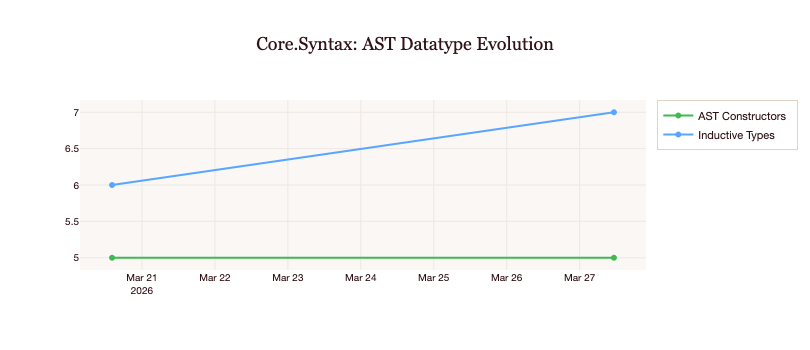

In [106]:
def track_inductives(filepath, sample_every=10):
    """Track inductive types and structures in a file over time using lean_parser."""
    history = []
    commits_touching = list(repo.iter_commits('main', paths=filepath))
    commits_touching.reverse()

    for i, c in enumerate(commits_touching):
        if i % sample_every != 0 and i != len(commits_touching) - 1:
            continue
        try:
            blob = c.tree / filepath
            content = blob.data_stream.read().decode('utf-8', errors='replace')
            result = parse_lean_file(content)

            inductives = {}
            for d in result['declarations']:
                if d['kind'] in ('inductive', 'structure'):
                    inductives[d['name']] = {
                        'kind': d['kind'],
                        'constructors': len(d.get('cases', {})),
                        'lines': d.get('num_lines', 0),
                    }

            history.append({
                'ts': datetime.fromtimestamp(c.authored_date),
                'hash': c.hexsha[:8],
                'inductives': inductives,
                'total_constructors': sum(v['constructors'] for v in inductives.values()),
                'total_types': len(inductives),
            })
        except (KeyError, TypeError):
            pass

    return pd.DataFrame(history)

# Track Core.Syntax evolution (AST types)
syntax_hist = track_inductives('VerifiedJS/Core/Syntax.lean', sample_every=10)
print(f'{len(syntax_hist)} snapshots')

fig = go.Figure()
fig.add_trace(go.Scatter(x=syntax_hist['ts'], y=syntax_hist['total_constructors'],
    name='AST Constructors', line=dict(color='#3fb950', width=2)))
fig.add_trace(go.Scatter(x=syntax_hist['ts'], y=syntax_hist['total_types'],
    name='Inductive Types', line=dict(color='#58a6ff', width=2)))
fig.update_layout(title='Core.Syntax: AST Datatype Evolution', height=350)
fig.show()

## 8. All Proof Files — Sorry Trajectory

python3(14661) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(14662) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(14708) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


ElaborateCorrect.lean: 2 snapshots


python3(14755) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(14756) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(14781) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(14829) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(14876) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(14930) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(14956) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(15005) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(15051) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(15100) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(15

ClosureConvertCorrect.lean: 56 snapshots


python3(17149) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(17150) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(17197) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(17243) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(17264) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(17312) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(17358) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(17379) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(17427) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(17474) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(17

...

LowerCorrect.lean: 2 snapshots


python3(18020) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18021) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18072) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


EmitCorrect.lean: 2 snapshots


python3(18118) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18119) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18229) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


EndToEnd.lean: 2 snapshots


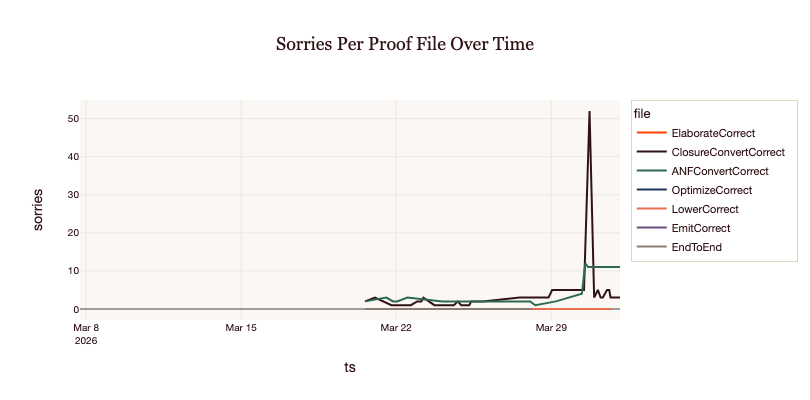

In [107]:
proof_files = [
    'VerifiedJS/Proofs/ElaborateCorrect.lean',
    'VerifiedJS/Proofs/ClosureConvertCorrect.lean',
    'VerifiedJS/Proofs/ANFConvertCorrect.lean',
    'VerifiedJS/Proofs/OptimizeCorrect.lean',
    'VerifiedJS/Proofs/LowerCorrect.lean',
    'VerifiedJS/Proofs/EmitCorrect.lean',
    'VerifiedJS/Proofs/EndToEnd.lean',
]

all_proof_hist = []
for pf in proof_files:
    h = track_file_evolution(pf, sample_every=10)
    h['file'] = pf.split('/')[-1].replace('.lean', '')
    all_proof_hist.append(h)
    print(f'{pf.split("/")[-1]}: {len(h)} snapshots')

proof_df = pd.concat(all_proof_hist, ignore_index=True)

fig = px.line(proof_df, x='ts', y='sorries', color='file',
    title='Sorries Per Proof File Over Time',
    height=400)
fig.show()

## 9. Agent Contribution Stats

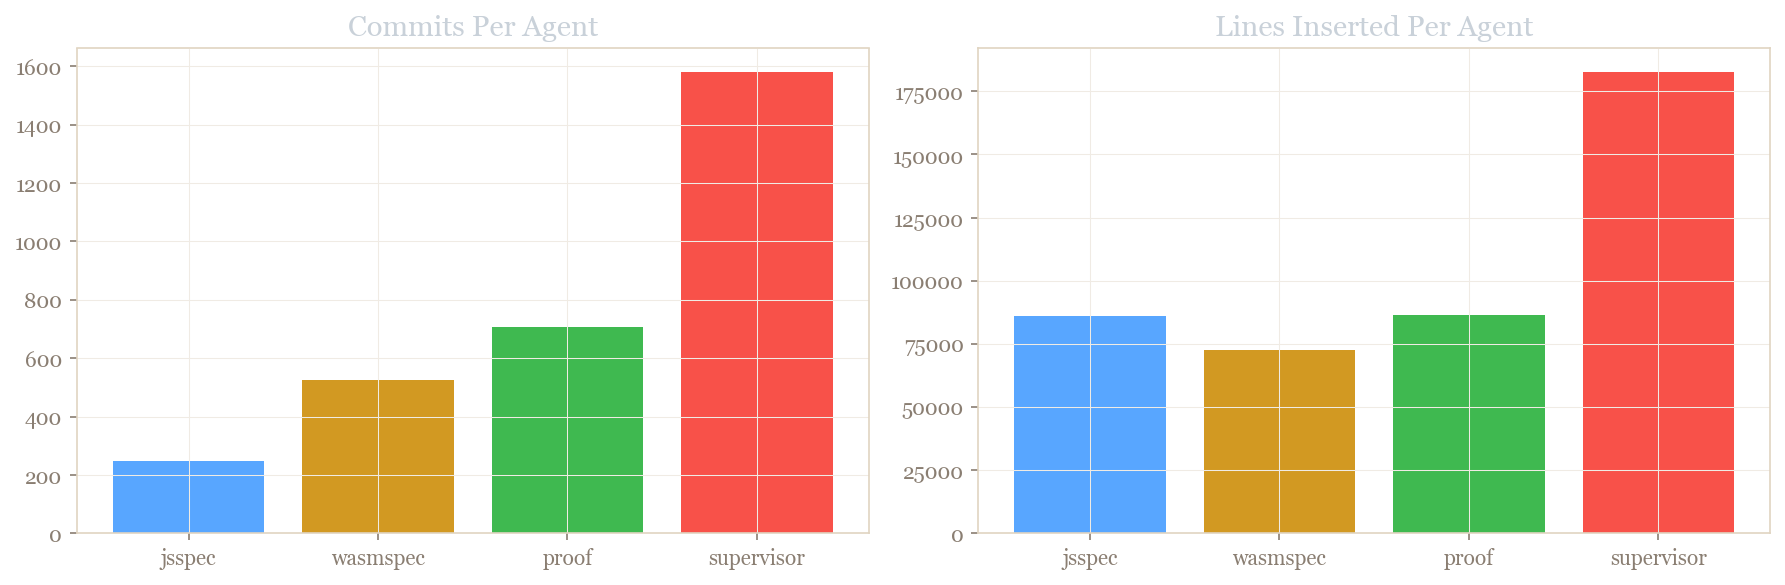

jsspec: 248 commits, 86,040 insertions
wasmspec: 525 commits, 72,423 insertions
proof: 708 commits, 86,270 insertions
supervisor: 1582 commits, 182,790 insertions


In [108]:
# Count commits per agent
agent_commits = Counter()
agent_insertions = Counter()
for _, row in df_auto.iterrows():
    for a in row['agents']:
        agent_commits[a] += 1
        agent_insertions[a] += row.get('insertions', 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
agents = ['jsspec', 'wasmspec', 'proof', 'supervisor']
colors = ['#58a6ff', '#d29922', '#3fb950', '#f85149']

ax1.bar(agents, [agent_commits.get(a, 0) for a in agents], color=colors)
ax1.set_title('Commits Per Agent', color='#c9d1d9')

ax2.bar(agents, [agent_insertions.get(a, 0) for a in agents], color=colors)
ax2.set_title('Lines Inserted Per Agent', color='#c9d1d9')

plt.tight_layout()
plt.show()

for a in agents:
    print(f'{a}: {agent_commits.get(a, 0)} commits, {agent_insertions.get(a, 0):,} insertions')

## 10. CC_SimRel Evolution — Track the Simulation Relation

In [109]:
def track_definition_body(filepath, def_name, sample_every=5):
    """Track how a def/structure body changes over commits using lean_parser."""
    history = []
    commits_touching = list(repo.iter_commits('main', paths=filepath))
    commits_touching.reverse()

    prev_body = None
    for i, c in enumerate(commits_touching):
        if i % sample_every != 0 and i != len(commits_touching) - 1:
            continue
        try:
            blob = c.tree / filepath
            content = blob.data_stream.read().decode('utf-8', errors='replace')
            result = parse_lean_file(content)

            body = None
            for d in result['declarations']:
                if d['name'] == def_name:
                    body = d['body']
                    break

            if body:
                changed = body != prev_body
                prev_body = body
                conjuncts = body.count('\u2227') + body.count('/\\\\')
                history.append({
                    'ts': datetime.fromtimestamp(c.authored_date),
                    'hash': c.hexsha[:8],
                    'body': body,
                    'changed': changed,
                    'conjuncts': conjuncts,
                    'body_lines': len(body.splitlines()),
                })
        except (KeyError, TypeError):
            pass

    return pd.DataFrame(history)

simrel_hist = track_definition_body(
    'VerifiedJS/Proofs/ClosureConvertCorrect.lean', 'CC_SimRel', sample_every=3)

print(f'{len(simrel_hist)} snapshots, {simrel_hist.changed.sum()} changes\n')
for _, row in simrel_hist[simrel_hist['changed'] == True].iterrows():
    show_lean(row['body'][:600], title=f"{row['ts'].strftime('%b %d %H:%M')} [{row['hash']}] — {row['conjuncts']} conjuncts, {row['body_lines']} lines")

python3(18308) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18309) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18356) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18403) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18449) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18471) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18518) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18564) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18585) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18632) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(18

184 snapshots, 12 changes



## 11. Behavioral Equivalence Relations — Evolution Over Time

In [ ]:
# Track all major simulation/behavioral relations across the proof files
relations_to_track = [
    ('VerifiedJS/Proofs/ClosureConvertCorrect.lean', 'CC_SimRel', 'CC SimRel (Core↔Flat)'),
    ('VerifiedJS/Proofs/ClosureConvertCorrect.lean', 'EnvCorr', 'EnvCorr'),
    ('VerifiedJS/Proofs/ClosureConvertCorrect.lean', 'HeapCorr', 'HeapCorr'),
    ('VerifiedJS/Proofs/ClosureConvertCorrect.lean', 'HeapInj', 'HeapInj'),
    ('VerifiedJS/Proofs/ANFConvertCorrect.lean', 'ANF_SimRel', 'ANF SimRel (Flat↔ANF)'),
    ('VerifiedJS/Wasm/Semantics.lean', 'ValueCorr', 'ValueCorr (Value↔IRValue)'),
]

for filepath, def_name, label in relations_to_track:
    h = track_definition_body(filepath, def_name, sample_every=5)
    if h.empty or h.changed.sum() == 0:
        continue
    print(f'\n{"="*70}')
    print(f' {label}: {len(h)} snapshots, {h.changed.sum()} changes')
    print(f'{"="*70}')
    for _, row in h[h['changed'] == True].iterrows():
        show_lean(row['body'][:700],
            title=f"{row['ts'].strftime('%b %d %H:%M')} [{row['hash']}] — {row['conjuncts']} conjuncts, {row['body_lines']} lines")

python3(26446) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(26473) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(26494) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(26541) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(26587) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(26608) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(26655) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(26701) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(26722) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(26769) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(26


 CC SimRel (Core↔Flat): 111 snapshots, 11 changes


python3(31281) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(31282) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(31329) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(31350) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(31397) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(31444) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(31491) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(31512) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(31559) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(31608) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(31


 EnvCorr: 105 snapshots, 3 changes


python3(36210) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(36211) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(36258) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(36306) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(36327) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(36373) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(36420) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(36441) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(36487) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(36534) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(36

...

python3(41106) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(41107) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(41128) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(41174) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(41222) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(41243) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(41292) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(41339) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(41360) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(41406) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(41


 HeapInj: 72 snapshots, 1 changes


python3(45876) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(45877) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(45932) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(45952) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(45999) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(46046) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(46092) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(46142) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(46163) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(46210) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(46


 ANF SimRel (Flat↔ANF): 35 snapshots, 5 changes


python3(47384) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(47385) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(47432) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(47479) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(47499) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(47547) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(47593) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(47641) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(47687) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(47769) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(47

## 12. Inductive Step/Steps/Behaves Relations — Evolution

In [ ]:
# Track the core inductive relations that define program semantics
inductives_to_track = [
    ('VerifiedJS/Core/Semantics.lean', 'Step', 'Core.Step'),
    ('VerifiedJS/Core/Semantics.lean', 'Behaves', 'Core.Behaves'),
    ('VerifiedJS/Flat/Semantics.lean', 'Step', 'Flat.Step'),
    ('VerifiedJS/Flat/Semantics.lean', 'Behaves', 'Flat.Behaves'),
    ('VerifiedJS/ANF/Semantics.lean', 'Step', 'ANF.Step'),
    ('VerifiedJS/ANF/Semantics.lean', 'Behaves', 'ANF.Behaves'),
    ('VerifiedJS/Wasm/Semantics.lean', 'IRStep', 'IR.IRStep'),
    ('VerifiedJS/Wasm/Semantics.lean', 'IRBehaves', 'IR.IRBehaves'),
    ('VerifiedJS/Wasm/Semantics.lean', 'Step', 'Wasm.Step'),
    ('VerifiedJS/Wasm/Semantics.lean', 'Behaves', 'Wasm.Behaves'),
]

def track_inductive_evolution(filepath, ind_name, sample_every=10):
    """Track an inductive's constructor count and body over commits using leansplitter."""
    history = []
    commits_touching = list(repo.iter_commits('main', paths=filepath))
    commits_touching.reverse()

    prev_body = None
    for i, c in enumerate(commits_touching):
        if i % sample_every != 0 and i != len(commits_touching) - 1:
            continue
        try:
            blob = c.tree / filepath
            content = blob.data_stream.read().decode('utf-8', errors='replace')
            result = parse_lean_file(content)

            body = None
            for d in result['declarations']:
                if d['name'] == ind_name:
                    body = d.get('body', '')
                    break

            if body:
                changed = body != prev_body
                # Count constructor pipes in the body text
                constructors = sum(1 for l in body.splitlines() if l.lstrip().startswith('|'))
                prev_body = body
                history.append({
                    'ts': datetime.fromtimestamp(c.authored_date),
                    'hash': c.hexsha[:8],
                    'body': body,
                    'changed': changed,
                    'constructors': constructors,
                    'lines': len(body.splitlines()),
                })
        except (KeyError, TypeError):
            pass
    return pd.DataFrame(history)

# Plot constructor counts over time
fig = go.Figure()
for filepath, ind_name, label in inductives_to_track:
    h = track_inductive_evolution(filepath, ind_name, sample_every=15)
    if not h.empty and h['constructors'].max() > 0:
        fig.add_trace(go.Scatter(x=h['ts'], y=h['constructors'], name=label, mode='lines+markers',
            marker=dict(size=4)))

fig.update_layout(title='Inductive Relation Constructor Count Over Time', height=450,
    yaxis_title='Constructors', xaxis_title='Date')
fig.show()

In [ ]:
# Show the latest version of each key inductive
print("Current state of key inductive relations:\n")
for filepath, ind_name, label in inductives_to_track:
    h = track_inductive_evolution(filepath, ind_name, sample_every=100)
    if not h.empty:
        latest = h.iloc[-1]
        show_lean(latest['body'][:800],
            title=f"{label} — {latest['constructors']} constructors, {latest['lines']} lines")

## 13. Step Function Evolution — Case-Level Diffs

The `step?` functions are large match expressions. We track changes at the **case level**:
showing only the cases that changed between commits, with `...` eliding the rest.

In [ ]:
def extract_step_cases(content, func_name='step?'):
    """Extract match cases from a step function using lean_parser."""
    return parse_step_function(content, func_name)


def diff_step_cases(old_cases, new_cases):
    """Compare two sets of step? cases. Return added, removed, changed."""
    added = {k: v for k, v in new_cases.items() if k not in old_cases}
    removed = {k: v for k, v in old_cases.items() if k not in new_cases}
    changed = {}
    for k in old_cases:
        if k in new_cases and old_cases[k] != new_cases[k]:
            changed[k] = (old_cases[k], new_cases[k])
    return added, removed, changed


def render_case_diff(added, removed, changed, title=''):
    """Render a case-level diff as syntax-highlighted HTML."""
    import html as _html
    parts = []
    if title:
        parts.append(f'<div style="font-family:Basier,sans-serif;font-size:12px;font-weight:600;color:#311317;margin-bottom:8px">{_html.escape(title)}</div>')
    
    if not added and not removed and not changed:
        parts.append('<div style="color:#8a7e72;font-size:11px">No case-level changes</div>')
        return HTML(''.join(parts))

    def _case_block(label, body, color, prefix=''):
        escaped = _html.escape(body.rstrip())
        # Truncate long cases
        lines = escaped.split('\n')
        if len(lines) > 8:
            escaped = '\n'.join(lines[:6]) + f'\n      ... ({len(lines)-6} more lines)'
        return (f'<div style="border-left:3px solid {color};padding:2px 8px;margin:4px 0;'
                f'background:{"#fef3f0" if color=="#ff4500" else "#f0f7ef" if color=="#2d6a4f" else "#faf7f4"}">'
                f'<span style="font-family:Basier,sans-serif;font-size:10px;color:{color};font-weight:600">'
                f'{prefix}{_html.escape(label)}</span>'
                f'<pre style="margin:2px 0;font-family:Basier Mono,monospace;font-size:11px;'
                f'line-height:1.5;white-space:pre-wrap">{escaped}</pre></div>')

    def _diff_block(label, old_body, new_body):
        """Render a side-by-side line diff for a changed case."""
        import difflib
        old_lines = old_body.rstrip().splitlines()
        new_lines = new_body.rstrip().splitlines()
        diff_html = []
        for tag, i1, i2, j1, j2 in difflib.SequenceMatcher(None, old_lines, new_lines).get_opcodes():
            if tag == 'equal':
                for line in old_lines[i1:i2][:2]:  # show max 2 context lines
                    diff_html.append(f'<div style="color:#8a7e72">{_html.escape(line)}</div>')
                if i2 - i1 > 2:
                    diff_html.append(f'<div style="color:#e0d4c1">  ... ({i2-i1-2} unchanged lines)</div>')
            elif tag == 'replace':
                for line in old_lines[i1:i2][:4]:
                    diff_html.append(f'<div style="background:#fef3f0;color:#ff4500">- {_html.escape(line)}</div>')
                if i2 - i1 > 4:
                    diff_html.append(f'<div style="color:#ff4500">  ... ({i2-i1-4} more removed)</div>')
                for line in new_lines[j1:j2][:4]:
                    diff_html.append(f'<div style="background:#f0f7ef;color:#2d6a4f">+ {_html.escape(line)}</div>')
                if j2 - j1 > 4:
                    diff_html.append(f'<div style="color:#2d6a4f">  ... ({j2-j1-4} more added)</div>')
            elif tag == 'delete':
                for line in old_lines[i1:i2][:4]:
                    diff_html.append(f'<div style="background:#fef3f0;color:#ff4500">- {_html.escape(line)}</div>')
                if i2 - i1 > 4:
                    diff_html.append(f'<div style="color:#ff4500">  ... ({i2-i1-4} more removed)</div>')
            elif tag == 'insert':
                for line in new_lines[j1:j2][:4]:
                    diff_html.append(f'<div style="background:#f0f7ef;color:#2d6a4f">+ {_html.escape(line)}</div>')
                if j2 - j1 > 4:
                    diff_html.append(f'<div style="color:#2d6a4f">  ... ({j2-j1-4} more added)</div>')
        body_html = ''.join(diff_html)
        return (f'<div style="border-left:3px solid #1d3557;padding:2px 8px;margin:4px 0;background:#faf7f4">'
                f'<span style="font-family:Basier,sans-serif;font-size:10px;color:#1d3557;font-weight:600">'
                f'\u25b3 {_html.escape(label)}</span>'
                f'<pre style="margin:2px 0;font-family:Basier Mono,monospace;font-size:11px;'
                f'line-height:1.5;white-space:pre-wrap">{body_html}</pre></div>')

    for k, v in added.items():
        parts.append(_case_block(k, v, '#2d6a4f', '+ '))
    for k, v in removed.items():
        parts.append(_case_block(k, v, '#ff4500', '\u2212 '))
    for k, (old, new) in changed.items():
        parts.append(_diff_block(k, old, new))

    summary = []
    if added: summary.append(f'<span style="color:#2d6a4f">+{len(added)} new</span>')
    if removed: summary.append(f'<span style="color:#ff4500">−{len(removed)} removed</span>')
    if changed: summary.append(f'<span style="color:#1d3557">△{len(changed)} changed</span>')
    parts.insert(1 if title else 0,
        f'<div style="font-size:10px;color:#8a7e72;margin-bottom:4px">{" · ".join(summary)}</div>')

    return HTML(f'<div style="background:#faf7f4;border:1px solid #e0d4c1;border-radius:6px;padding:12px;margin:8px 0">{"".join(parts)}</div>')


# Track step? functions across all ILs
step_functions = [
    ('VerifiedJS/Core/Semantics.lean', 'step?', 'Core.step?'),
    ('VerifiedJS/Flat/Semantics.lean', 'step?', 'Flat.step?'),
    ('VerifiedJS/ANF/Semantics.lean', 'step?', 'ANF.step?'),
]

for filepath, func_name, label in step_functions:
    commits_touching = list(repo.iter_commits('main', paths=filepath))
    commits_touching.reverse()

    # Sample commits
    sampled = commits_touching  # check ALL commits, no sampling

    prev_cases = None
    changes = []
    first_body = last_body = None
    for c in sampled:
        try:
            blob = c.tree / filepath
            content = blob.data_stream.read().decode('utf-8', errors='replace')
            cases, body = extract_step_cases(content, func_name)
            if not cases:
                continue
            if first_body is None:
                first_body = body
            last_body = body

            if prev_cases is not None:
                added, removed, changed = diff_step_cases(prev_cases, cases)
                if added or removed or changed:
                    changes.append({
                        'ts': datetime.fromtimestamp(c.authored_date),
                        'hash': c.hexsha[:8],
                        'added': added, 'removed': removed, 'changed': changed,
                        'total_cases': len(cases),
                    })
            prev_cases = cases
        except (KeyError, TypeError):
            pass

    print(f'\n{"="*70}')
    print(f' {label}: {len(changes)} case-level changes across {len(sampled)} sampled commits')
    print(f' Cases: {len(prev_cases or {})} current')
    print(f'{"="*70}')

    # Show first and last version (truncated)
    if first_body:
        fl = first_body.splitlines()
        show_lean('\n'.join(fl[:15]) + f'\n  ... ({len(fl)} total lines)',
            title=f'{label} — FIRST VERSION')
    if last_body and last_body != first_body:
        ll = last_body.splitlines()
        show_lean('\n'.join(ll[:15]) + f'\n  ... ({len(ll)} total lines)',
            title=f'{label} — CURRENT VERSION')

    # Show each change as a case-level diff
    for ch in changes:
        display(render_case_diff(ch['added'], ch['removed'], ch['changed'],
            title=f"{ch['ts'].strftime('%b %d %H:%M')} [{ch['hash']}] — {ch['total_cases']} cases"))

In [ ]:
# Summary chart: case count per step function over time
fig = go.Figure()
for filepath, func_name, label in step_functions:
    commits_touching = list(repo.iter_commits('main', paths=filepath))
    commits_touching.reverse()
    sampled = commits_touching
    
    data_points = []
    for c in sampled:
        try:
            blob = c.tree / filepath
            content = blob.data_stream.read().decode('utf-8', errors='replace')
            cases, _ = extract_step_cases(content, func_name)
            if cases:
                data_points.append({
                    'ts': datetime.fromtimestamp(c.authored_date),
                    'cases': len(cases) - 1,  # subtract header
                })
        except (KeyError, TypeError):
            pass
    
    if data_points:
        dp = pd.DataFrame(data_points)
        fig.add_trace(go.Scatter(x=dp['ts'], y=dp['cases'], name=label,
            mode='lines+markers', marker=dict(size=4)))

fig.update_layout(title='Step Function Case Count Over Time', height=400,
    yaxis_title='Match Cases', xaxis_title='Date')
fig.show()